# Association Rule Mining — Market Basket Analysis with Apriori & FP-Growth

**Author:** Shivani Bokka
**Dataset:** [Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail) (UCI) — 541,909 real transactions from a UK online gift retailer
**Goal:** Discover which products are bought together, and turn co-occurrence into actionable rules

---

## What Is This Notebook About?

Every time a store says *"customers who bought this also bought that,"* there's association rule mining
underneath. It's the unsupervised technique for finding **items that co-occur** in transactions — the
classic "beer and diapers" of retail analytics — and it's the one major unsupervised family the other
notebooks in this series don't touch.

Unlike clustering (which groups *rows*) or dimensionality reduction (which compresses *columns*),
association rule mining finds **patterns across items within transactions**. There are no labels and no
target — just baskets of items and the question: *what goes with what?*

---

## Models Covered

| # | Method | Core Idea |
|---|--------|-----------|
| 1 | **Apriori** | Build frequent itemsets bottom-up, pruning any set whose subset is already infrequent |
| 2 | **FP-Growth** | Same frequent itemsets, but via a compressed prefix-tree — much faster on large data |
| 3 | **Association Rules** | Turn frequent itemsets into `IF antecedent THEN consequent` rules, scored by support / confidence / lift |

---


## Section 1 — Imports and Setup

We use **mlxtend** for the Apriori / FP-Growth algorithms and rule generation, plus the usual
pandas / matplotlib / seaborn stack.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings
warnings.filterwarnings('ignore')

# mlxtend — frequent itemsets + association rules
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_colwidth', 60)
RANDOM_STATE = 42

print("All libraries imported successfully!")

All libraries imported successfully!


## Section 2 — The Core Concepts

An **association rule** has the form **{antecedent} → {consequent}**, e.g.
*{green alarm clock} → {red alarm clock}*. Three numbers tell you whether a rule is worth anything:

| Metric | Question it answers | Formula | Range |
|--------|---------------------|---------|-------|
| **Support** | How often does this itemset appear at all? | transactions containing the set ÷ all transactions | 0–1 |
| **Confidence** | Given the antecedent, how often does the consequent follow? | support(A ∪ B) ÷ support(A) | 0–1 |
| **Lift** | Does A make B **more** likely than chance? | confidence(A→B) ÷ support(B) | 0–∞ |

**Lift is the one that matters most.**
- **Lift = 1** → A and B are independent (the rule tells you nothing).
- **Lift > 1** → A and B appear together *more* than chance — a genuine association.
- **Lift < 1** → they *repel* each other (buying A makes B less likely).

> **Why not just confidence?** A rule can have high confidence purely because the consequent is popular.
> If 80% of all baskets contain a shopping bag, then *anything → shopping bag* has 80% confidence but is
> useless. Lift corrects for that by dividing out the consequent's own popularity.

There's also **conviction** and **leverage** (mlxtend computes them for free) — refinements on the same idea.


## Section 3 — Load and Clean the Data

The Online Retail dataset is one row **per line-item** (an invoice with 5 products is 5 rows). We:
1. Download it once and cache it locally (it's a ~23 MB Excel file).
2. Drop cancelled orders (invoice numbers starting with `C`), missing product descriptions, and non-positive
   quantities — all of which are returns or data-entry noise, not real purchases.
3. Focus on a **single country** so the item vocabulary and basket count stay manageable (the basket matrix
   grows with both transactions *and* distinct items). We use **France** — the classic mlxtend example —
   then you can swap in any country.

In [2]:
# Download once, then load from local cache (data/ is gitignored)
os.makedirs('data', exist_ok=True)
cache_path = 'data/online_retail.xlsx'
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'

if not os.path.exists(cache_path):
    print("Downloading Online Retail from UCI (~23 MB, one-time)...")
    import urllib.request
    urllib.request.urlretrieve(url, cache_path)
    print("Saved to", cache_path)

df = pd.read_excel(cache_path)
print(f"Raw shape: {df.shape}")

# --- Clean ---
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df = df[~df['InvoiceNo'].str.startswith('C')]          # drop cancellations
df = df.dropna(subset=['Description'])                  # drop missing product names
df = df[df['Quantity'] > 0]                             # drop non-positive quantities
df['Description'] = df['Description'].str.strip()

print(f"Cleaned shape: {df.shape}")
print(f"Unique invoices: {df['InvoiceNo'].nunique():,}")
print(f"Unique products: {df['Description'].nunique():,}")
print(f"Countries: {df['Country'].nunique()}")
print("\nTop 5 countries by transaction count:")
print(df['Country'].value_counts().head())

Raw shape: (541909, 8)


Cleaned shape: (530693, 8)
Unique invoices: 20,136
Unique products: 4,065
Countries: 38

Top 5 countries by transaction count:
Country
United Kingdom    485694
Germany             9042
France              8408
EIRE                7894
Spain               2485
Name: count, dtype: int64


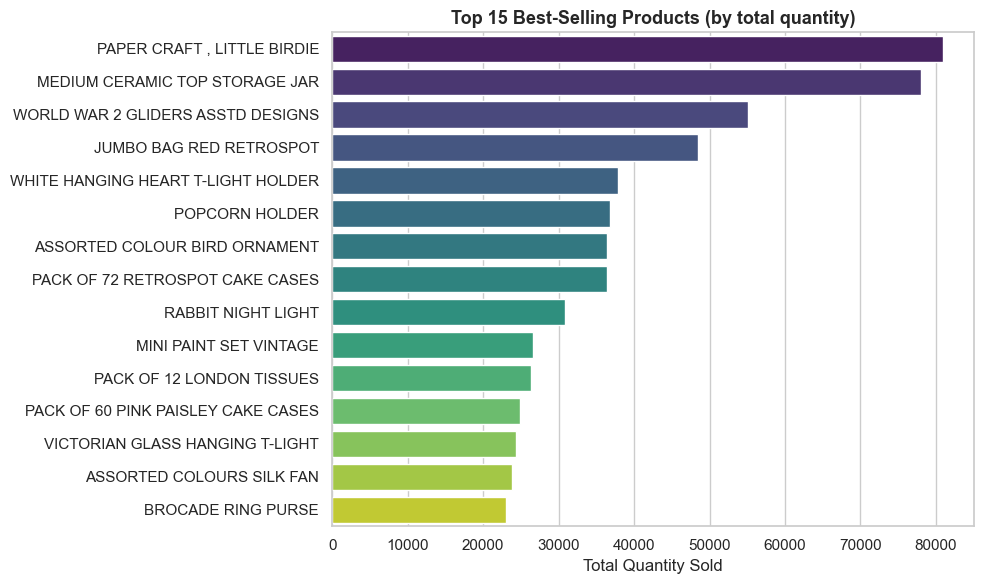

In [3]:
# Quick EDA — the 15 best-selling products (by total quantity) across the whole dataset
top_products = (df.groupby('Description')['Quantity'].sum()
                  .sort_values(ascending=False).head(15))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 15 Best-Selling Products (by total quantity)', fontsize=13, fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('')
plt.tight_layout()
plt.show()

### How to Read This Chart: Best-Selling Products

This is a plain popularity ranking — the raw ingredients association mining works on. Notice these are
mostly cheap, high-volume gift items (decorations, bags, tea-things). High raw popularity is exactly why
we'll need **lift** rather than confidence later: a rule that just predicts "popular item" is worthless.

## Section 4 — Build the Basket Matrix

Association mining needs a **one-hot basket matrix**: one row per invoice, one column per product, `True`
if that product is in that invoice. We pivot the France transactions into that shape.

In [4]:
# One country keeps the item vocabulary small enough for Apriori
country = 'France'
country_df = df[df['Country'] == country]

# Pivot: rows = invoices, columns = products, values = total quantity -> boolean "in basket"
basket = (country_df
          .groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().fillna(0))
basket = (basket > 0)                       # mlxtend wants a boolean one-hot matrix

print(f"Country: {country}")
print(f"Basket matrix shape: {basket.shape}   (invoices x distinct products)")
print(f"Average distinct items per basket: {basket.sum(axis=1).mean():.1f}")

Country: France
Basket matrix shape: (392, 1563)   (invoices x distinct products)
Average distinct items per basket: 21.4


## Section 5 — Apriori: Frequent Itemsets

**Apriori** finds every itemset that appears in at least `min_support` of baskets. Its trick is the
*Apriori property*: **if an itemset is infrequent, every superset of it is also infrequent** — so once
`{A, B}` is rare, we never bother checking `{A, B, C}`. This pruning is what makes the combinatorial
explosion tractable.

We set `min_support=0.05` — an itemset must appear in at least 5% of French invoices to count.

In [5]:
t0 = time.time()
frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True)
apriori_time = time.time() - t0

frequent_itemsets['n_items'] = frequent_itemsets['itemsets'].apply(len)
print(f"Apriori found {len(frequent_itemsets)} frequent itemsets in {apriori_time:.3f}s")
print(f"\nItemset sizes:\n{frequent_itemsets['n_items'].value_counts().sort_index()}")
print("\nTop 10 single items by support:")
singles = frequent_itemsets[frequent_itemsets['n_items'] == 1].copy()
singles['item'] = singles['itemsets'].apply(lambda s: list(s)[0])
print(singles.sort_values('support', ascending=False)[['item', 'support']].head(10).to_string(index=False))

Apriori found 195 frequent itemsets in 0.014s

Itemset sizes:
n_items
1    77
2    93
3    22
4     3
Name: count, dtype: int64

Top 10 single items by support:
                              item  support
                           POSTAGE 0.765306
                RABBIT NIGHT LIGHT 0.188776
     RED TOADSTOOL LED NIGHT LIGHT 0.181122
  PLASTERS IN TIN WOODLAND ANIMALS 0.170918
     PLASTERS IN TIN CIRCUS PARADE 0.168367
ROUND SNACK BOXES SET OF4 WOODLAND 0.158163
           LUNCH BAG RED RETROSPOT 0.153061
  LUNCH BOX WITH CUTLERY RETROSPOT 0.142857
          RED RETROSPOT MINI CASES 0.137755
       SET/6 RED SPOTTY PAPER CUPS 0.137755


### How to Read This: Frequent Itemsets

Each row is a set of products that co-occur in at least 5% of baskets, with its `support`. Size-1 itemsets
are just popular individual products; size-2+ itemsets are the interesting part — combinations that show up
together often enough to build rules from. If you got very few multi-item sets, lower `min_support`; if you
got thousands, raise it.

## Section 6 — Generate Association Rules

Now we turn frequent itemsets into **rules** and rank them by **lift**. We keep only rules with lift > 1
(genuine positive association) and reasonable confidence.

In [6]:
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)

# Make antecedents/consequents readable
rules['antecedents_str'] = rules['antecedents'].apply(lambda s: ', '.join(list(s)))
rules['consequents_str'] = rules['consequents'].apply(lambda s: ', '.join(list(s)))

print(f"Generated {len(rules)} rules with lift > 1.")
print("\nTop 10 rules by lift:")
show_cols = ['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']
top_rules = rules.sort_values('lift', ascending=False).head(10)
print(top_rules[show_cols].to_string(index=False))

Generated 348 rules with lift > 1.

Top 10 rules by lift:
                                               antecedents_str                                                consequents_str  support  confidence      lift
                                    PACK OF 6 SKULL PAPER CUPS                                   PACK OF 6 SKULL PAPER PLATES 0.051020    0.800000 14.254545
                                  PACK OF 6 SKULL PAPER PLATES                                     PACK OF 6 SKULL PAPER CUPS 0.051020    0.909091 14.254545
                                  CHILDRENS CUTLERY DOLLY GIRL                                     CHILDRENS CUTLERY SPACEBOY 0.063776    0.892857 12.962963
                                    CHILDRENS CUTLERY SPACEBOY                                   CHILDRENS CUTLERY DOLLY GIRL 0.063776    0.925926 12.962963
ALARM CLOCK BAKELIKE PINK, POSTAGE, ALARM CLOCK BAKELIKE GREEN                                       ALARM CLOCK BAKELIKE RED 0.056122    0.916667  9.711712


### How to Read This: The Rules Table

Read a row as **IF a basket contains {antecedents} THEN it also contains {consequents}**, with:
- **support** — how common this whole combination is (higher = applies to more baskets).
- **confidence** — of baskets with the antecedent, the fraction that also have the consequent.
- **lift** — how much more likely the consequent is *given* the antecedent, versus its baseline rate.
  **This is your ranking column.** A lift of 8 means the pairing happens 8× more than chance.

Notice the top-lift rules are often between **matching product variants** (same item in different colors, or
pieces of a themed set) — which is exactly the kind of "complete the set" cross-sell a retailer can act on.

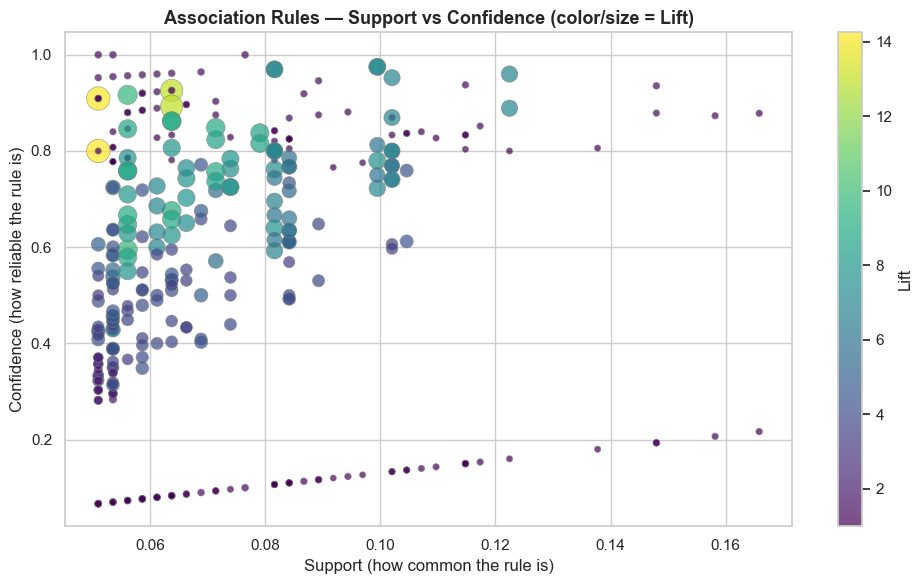

In [7]:
# Scatter: every rule as a point (support vs confidence), colored & sized by lift
plt.figure(figsize=(10, 6))
sc = plt.scatter(rules['support'], rules['confidence'],
                 c=rules['lift'], s=rules['lift'] * 20,
                 cmap='viridis', alpha=0.7, edgecolors='grey', linewidths=0.5)
plt.colorbar(sc, label='Lift')
plt.xlabel('Support (how common the rule is)')
plt.ylabel('Confidence (how reliable the rule is)')
plt.title('Association Rules — Support vs Confidence (color/size = Lift)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read This Chart: The Rule Scatter

Every point is one rule. This single plot captures the fundamental trade-off in rule mining:
- **Far right** (high support): rules that apply to many baskets — but common combos are rarely surprising.
- **Top** (high confidence): rules that are reliable when they fire.
- **Bright yellow / large** (high lift): the *interesting* rules — strong associations beyond chance.

The sweet spot is the **top-right with bright color**: reliable, reasonably common, AND a strong lift. In
practice you'll rarely get all three — high-lift rules tend to have low support (niche but strong), which is
fine: a niche "complete the set" recommendation is still valuable.

## Section 7 — FP-Growth: The Faster Alternative

Apriori re-scans the data for every itemset size, which gets slow on large datasets. **FP-Growth** builds a
compressed **FP-tree** (a prefix tree of all transactions) once, then mines frequent itemsets directly from
it — no repeated candidate-generation passes. It returns the **same frequent itemsets**, just faster.

In [8]:
t0 = time.time()
fp_itemsets = fpgrowth(basket, min_support=0.05, use_colnames=True)
fp_time = time.time() - t0

print(f"Apriori   : {len(frequent_itemsets):3d} itemsets in {apriori_time:.4f}s")
print(f"FP-Growth : {len(fp_itemsets):3d} itemsets in {fp_time:.4f}s")

# Verify they find the SAME itemsets (order aside)
set_apriori = set(frozenset(s) for s in frequent_itemsets['itemsets'])
set_fp      = set(frozenset(s) for s in fp_itemsets['itemsets'])
print(f"\nIdentical itemsets found? {set_apriori == set_fp}")
if apriori_time > 0 and fp_time > 0:
    print(f"FP-Growth speedup on this basket: {apriori_time / fp_time:.1f}x")
print("\nNote: on a small single-country basket the gap is modest; on the full multi-country dataset")
print("(or any large transaction log) FP-Growth's advantage becomes dramatic.")

Apriori   : 195 itemsets in 0.0140s
FP-Growth : 195 itemsets in 0.0190s

Identical itemsets found? True
FP-Growth speedup on this basket: 0.7x

Note: on a small single-country basket the gap is modest; on the full multi-country dataset
(or any large transaction log) FP-Growth's advantage becomes dramatic.


## Section 8 — Interpreting a Rule as a Business Decision

The algorithm's output is only useful once it becomes an action. Let's take the single highest-lift rule and
read it the way a merchandiser would.

In [9]:
best = rules.sort_values('lift', ascending=False).iloc[0]

print("HIGHEST-LIFT RULE")
print("=" * 60)
print(f"  IF a basket contains : {best['antecedents_str']}")
print(f"  THEN it also contains: {best['consequents_str']}")
print("-" * 60)
print(f"  Support    : {best['support']:.3f}  (appears in {best['support']*100:.1f}% of French baskets)")
print(f"  Confidence : {best['confidence']:.3f}  ({best['confidence']*100:.0f}% of the time the rule holds)")
print(f"  Lift       : {best['lift']:.2f}  (that's {best['lift']:.1f}x more likely than chance)")
print("=" * 60)
print("\nAction: place these products near each other, bundle them, or recommend one when the")
print("other is added to cart. High lift + high confidence = a reliable cross-sell.")

HIGHEST-LIFT RULE
  IF a basket contains : PACK OF 6 SKULL PAPER CUPS
  THEN it also contains: PACK OF 6 SKULL PAPER PLATES
------------------------------------------------------------
  Support    : 0.051  (appears in 5.1% of French baskets)
  Confidence : 0.800  (80% of the time the rule holds)
  Lift       : 14.25  (that's 14.3x more likely than chance)

Action: place these products near each other, bundle them, or recommend one when the
other is added to cart. High lift + high confidence = a reliable cross-sell.


## Section 9 — Summary and Key Takeaways

### What You Built
- Turned 500k raw line-items into a clean **basket matrix**.
- Mined **frequent itemsets** with Apriori and, faster, with FP-Growth (identical results).
- Generated **association rules** and ranked them by **lift** — the metric that finds genuine associations,
  not just popular items.
- Read a rule as a concrete **cross-sell decision**.

### When to Use Association Rule Mining
- **Market basket analysis** — product placement, bundling, "frequently bought together."
- **Recommendation seeding** — cheap, interpretable co-occurrence rules before reaching for a full recommender.
- **Any co-occurrence problem** — symptoms in diagnoses, pages in web sessions, tags on content.

### Common Mistakes to Avoid
1. **Trusting confidence alone** — always check **lift**. High confidence often just means the consequent is popular.
2. **Setting `min_support` too low** — the number of itemsets explodes combinatorially and mining crawls.
3. **Not cleaning cancellations/returns** — negative quantities and `C` invoices create phantom associations.
4. **Mining across everything at once** — segment by country / season / customer type; associations differ by context.

### The Bigger Picture
This completes the unsupervised tour: **clustering** groups rows, **dimensionality reduction** compresses
columns, **anomaly detection** flags the rare, **topic modeling** finds themes in text, and **association
rules** find what co-occurs. Five different questions, all answered without a single label.